# Task 3: Granulometry Benchmarking â€” Qwen2.5-VL-3B (Base Model)

Benchmark the un-fine-tuned model on 108 test images of concrete aggregate.
Classify each image by max particle size (8/16/32mm) and grading (coarse/medium/fine).

Two modes:
- **Zero-shot** (1500px): No reference image
- **Few-shot** (ref@800 + test@1400): Reference classification chart included

This establishes the baseline that Task 4 (LoRA fine-tuning) should improve.

In [1]:
import os, json, re, time, torch, gc
import numpy as np
from PIL import Image
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

print(f'GPUs: {torch.cuda.device_count()}')
for i in range(torch.cuda.device_count()):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)} â€” {torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB')

GPUs: 2
  GPU 0: Tesla V100-PCIE-16GB â€” 16.9 GB
  GPU 1: Tesla V100-PCIE-16GB â€” 16.9 GB


## Config & Prompts

In [2]:
TEST_DIR = '../../datasets/granulometry/test'
MANIFEST = '../../datasets/granulometry/test_manifest.json'
REF_IMAGE_PATH = 'examples_classification_data.png'
ORIGINAL_GSD = 8.0
MAX_DIM_ZS = 1500   # zero-shot: single image
MAX_DIM_FS = 1400   # few-shot: test image (ref is kept at native ~600x445)
IMG_SIZE = 500       # preview thumbnails only

PROMPT_ZERO_SHOT = '''This is a top-down photo of concrete aggregate. GSD = {gsd:.1f} px/mm.

Classify it on two axes:

MAX PARTICLE SIZE - estimate the largest stone's width in pixels, divide by {gsd:.1f} to get mm, round to 8, 16, or 32.
Reference: at {gsd:.1f} px/mm, a 8mm stone = ~{eight:.0f}px wide, 16mm = ~{sixteen:.0f}px, 32mm = ~{thirtytwo:.0f}px.

GRADING - describes the size distribution relative to the max size:
- COARSE: most particles are similar in size, close to the max. Few small particles. Looks uniform.
- MEDIUM: moderate mix of large and small.
- FINE: wide range of sizes. Many small particles fill gaps between larger ones. Looks dense and packed.

Example: "coarse 32mm" = mostly 16-32mm stones, few small ones. "fine 32mm" = some 32mm stones but lots of 4-16mm particles filling every gap.

Respond with ONLY a JSON object (no other text):
{{"max_particle_size_mm": <8, 16, or 32>, "grading": "<coarse, medium, or fine>"}}'''

PROMPT_FEW_SHOT_REF = '''Reference chart: 3x3 grid of concrete aggregate photos.

COLUMNS (left to right) = max particle size: 8mm | 16mm | 32mm
ROWS (top to bottom) = grading: A (coarse) | B (medium) | C (fine)

What grading means - it describes size DISTRIBUTION, not absolute size:
- COARSE (A): particles are mostly the same size, close to the max. Few small ones. Uniform texture.
- MEDIUM (B): moderate mix of large and small.
- FINE (C): many different sizes. Small particles fill all gaps between big ones. Dense, packed texture.

Look at column 32mm: row A has mostly big uniform stones, row C has big stones BUT also lots of small ones filling every gap. That is the difference.'''

PROMPT_FEW_SHOT_QUERY = '''Classify this photo. GSD = {gsd:.1f} px/mm.

Compare to the reference grid:
1. Which COLUMN? (8, 16, or 32mm) - match the largest stone size.
   Hint: at {gsd:.1f} px/mm, a 8mm stone = ~{eight:.0f}px wide, 16mm = ~{sixteen:.0f}px, 32mm = ~{thirtytwo:.0f}px.
2. Which ROW? (A=coarse, B=medium, C=fine)
   - Uniform texture, most stones similar size = coarse (A)
   - Dense packed texture, many small particles filling gaps between big ones = fine (C)
   - In between = medium (B)

Respond with ONLY a JSON object (no other text):
{{"max_particle_size_mm": <8, 16, or 32>, "grading": "<coarse, medium, or fine>"}}'''


## Load Dataset

In [3]:
with open(MANIFEST) as f:
    manifest = json.load(f)

print(f'Total test images: {len(manifest)}')
cls_counts = Counter(e['class'] for e in manifest)
for cls in sorted(cls_counts):
    print(f'  {cls}: {cls_counts[cls]} images')

Total test images: 108
  A16: 12 images
  A32: 12 images
  A8: 12 images
  B16: 12 images
  B32: 12 images
  B8: 12 images
  C16: 12 images
  C32: 12 images
  C8: 12 images


Reference image: (600, 445)


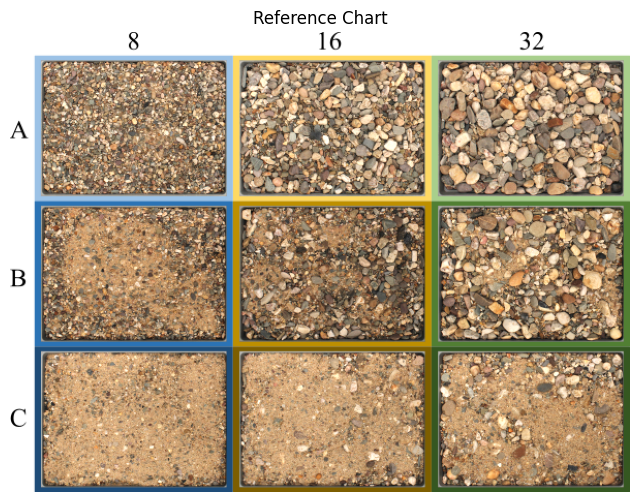

In [4]:
# Load reference image â€” white background, keep at native size
ref_image = None
if os.path.exists(REF_IMAGE_PATH):
    raw_ref = Image.open(REF_IMAGE_PATH).convert('RGBA')
    white_bg = Image.new('RGBA', raw_ref.size, (255, 255, 255, 255))
    ref_image = Image.alpha_composite(white_bg, raw_ref).convert('RGB')
    ref_image.thumbnail((800, 800), Image.Resampling.LANCZOS)
    print(f'Reference image: {ref_image.size}')
    plt.figure(figsize=(8, 6))
    plt.imshow(ref_image); plt.title('Reference Chart'); plt.axis('off'); plt.show()
else:
    print(f'WARNING: {REF_IMAGE_PATH} not found')

## Load Model

In [5]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

processor = AutoProcessor.from_pretrained('Qwen/Qwen2.5-VL-3B-Instruct')
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    'Qwen/Qwen2.5-VL-3B-Instruct', torch_dtype=torch.bfloat16,
    device_map='auto', max_memory={0: '6GiB', 1: '15GiB'},
)
print(f'Model loaded.')
for i in range(torch.cuda.device_count()):
    print(f'  GPU {i}: {torch.cuda.memory_allocated(i)/1e9:.1f} GB')

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-12 02:00:01.451955: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-12 02:00:01.452007: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-12 02:00:01.453510: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-12 02:00:01.462209: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary

Model loaded.
  GPU 0: 4.0 GB
  GPU 1: 3.6 GB


## Helper Functions

In [15]:
def parse_response(raw):
    raw = re.sub(r'```json\s*', '', raw)
    raw = re.sub(r'```\s*', '', raw).strip()
    try:
        obj = json.loads(raw)
        if isinstance(obj, dict): return obj
    except: pass
    m = re.search(r'\{.*\}', raw, re.DOTALL)
    if m:
        try: return json.loads(m.group())
        except: pass
    size_m = re.search(r'"max_particle_size_mm"\s*:\s*(\d+)', raw)
    grad_m = re.search(r'"grading"\s*:\s*"(\w+)"', raw)
    if size_m and grad_m:
        return {'max_particle_size_mm': int(size_m.group(1)), 'grading': grad_m.group(1)}
    return None

def infer(img_path, mode='zero-shot', ref_img=None):
    image = Image.open(img_path).convert('RGB')
    max_dim = MAX_DIM_FS if (mode == 'few-shot' and ref_img is not None) else MAX_DIM_ZS
    orig_max = max(image.size)
    scale = min(max_dim / orig_max, 1.0)
    if scale < 1.0:
        image = image.resize((int(image.width * scale), int(image.height * scale)), Image.Resampling.LANCZOS)
    actual_gsd = ORIGINAL_GSD * scale
    if mode == 'few-shot' and ref_img is not None:
        msgs = [{'role':'user','content':[
            {'type':'image','image':ref_img},
            {'type':'text','text':PROMPT_FEW_SHOT_REF},
            {'type':'image','image':image},
            {'type':'text','text':PROMPT_FEW_SHOT_QUERY.format(gsd=actual_gsd, eight=8*actual_gsd, sixteen=16*actual_gsd, thirtytwo=32*actual_gsd)},
        ]}]
        images = [ref_img, image]
    else:
        msgs = [{'role':'user','content':[
            {'type':'image','image':image},
            {'type':'text','text':PROMPT_ZERO_SHOT.format(gsd=actual_gsd, eight=8*actual_gsd, sixteen=16*actual_gsd, thirtytwo=32*actual_gsd)},
        ]}]
        images = [image]
    text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=images, return_tensors='pt', padding=True).to(model.device)
    t = time.time()
    with torch.no_grad():
        ids = model.generate(**inputs, max_new_tokens=128, temperature=0.7, do_sample=True)
    elapsed = time.time() - t
    out = processor.batch_decode(ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
    del inputs, ids; image.close(); torch.cuda.empty_cache()
    return out.strip(), elapsed

def run_benchmark(manifest, mode, ref_img=None):
    results = []
    correct_size = 0; correct_grading = 0; valid_json = 0; total_time = 0
    for i, entry in enumerate(manifest):
        img_path = os.path.join(TEST_DIR, entry['image'])
        if not os.path.exists(img_path): continue
        raw, elapsed = infer(img_path, mode=mode, ref_img=ref_img)
        total_time += elapsed
        parsed = parse_response(raw)
        gt_size = entry['max_particle_size_mm']; gt_grading = entry['grading']
        size_ok = False; grading_ok = False; is_valid = parsed is not None
        if is_valid:
            valid_json += 1
            pred_size = parsed.get('max_particle_size_mm')
            if isinstance(pred_size, str): pred_size = int(pred_size) if pred_size.isdigit() else None
            if pred_size == gt_size: size_ok = True; correct_size += 1
            if parsed.get('grading', '').lower() == gt_grading: grading_ok = True; correct_grading += 1
        results.append({
            'image': entry['image'], 'class': entry['class'],
            'gt_size': gt_size, 'gt_grading': gt_grading,
            'predicted': parsed, 'raw': raw,
            'size_correct': size_ok, 'grading_correct': grading_ok,
            'valid_json': is_valid, 'time_s': round(elapsed, 2),
        })
        if (i+1) % 10 == 0:
            n = i + 1
            print(f'[{n}/{len(manifest)}] Size: {correct_size}/{n} ({correct_size/n*100:.0f}%) | '
                  f'Grading: {correct_grading}/{n} ({correct_grading/n*100:.0f}%) | '
                  f'JSON: {valid_json}/{n} | Avg: {total_time/n:.1f}s')
    return results, correct_size, correct_grading, valid_json, total_time

print('Helpers ready.')


Helpers ready.


## Quick Test (hidden)
Expand to run a sanity check — 1 image per class, zero-shot only.

In [ ]:
# Quick test: 1 image per class, zero-shot
all_classes = sorted(set(e['class'] for e in manifest))
quick_test = [next(e for e in manifest if e['class'] == cls) for cls in all_classes]
print(f'Quick test: {len(quick_test)} images — {[e["class"] for e in quick_test]}')

for entry in quick_test:
    img_path = os.path.join(TEST_DIR, entry['image'])
    raw, elapsed = infer(img_path, mode='zero-shot')
    parsed = parse_response(raw)
    gt_size = entry['max_particle_size_mm']; gt_grading = entry['grading']
    if parsed:
        ps = parsed.get('max_particle_size_mm'); pg = parsed.get('grading','').lower()
        if isinstance(ps, str): ps = int(ps) if ps.isdigit() else None
        sv = '✓' if ps == gt_size else '✗'; gv = '✓' if pg == gt_grading else '✗'
        print(f"{entry['class']:>3} | GT: {gt_size}mm {gt_grading} | Pred: {ps}mm {pg} | Size {sv} Grading {gv} | {elapsed:.1f}s")
    else:
        print(f"{entry['class']:>3} | GT: {gt_size}mm {gt_grading} | PARSE FAIL | {elapsed:.1f}s | Raw: {raw[:80]}")


## Diagnostic: Natural Language Reasoning (hidden)
Expand to run zero-shot and few-shot diagnostics with chain-of-thought reasoning.

In [14]:
# Zero-shot diagnostic: 4 extreme classes, natural language
DIAG_ZS = '''This is a top-down photo of concrete aggregate. GSD = {gsd:.1f} px/mm.

Classify it on two axes:
MAX PARTICLE SIZE — estimate the largest stone width in pixels, divide by {gsd:.1f} to get mm, round to 8, 16, or 32.
GRADING — describes size distribution relative to max size:
- COARSE: most particles similar size, close to max. Few small particles. Uniform texture.
- MEDIUM: moderate mix of large and small.
- FINE: wide range of sizes. Many small particles fill gaps between larger ones. Dense, packed texture.

Think step by step, then state: max size, grading, and your confidence.'''

for cls in ['A8', 'A32', 'C8', 'C32']:
    entry = next(e for e in manifest if e['class'] == cls)
    img_path = os.path.join(TEST_DIR, entry['image'])
    image = Image.open(img_path).convert('RGB')
    scale = min(MAX_DIM_ZS / max(image.size), 1.0)
    actual_gsd = ORIGINAL_GSD * scale
    if scale < 1.0:
        image = image.resize((int(image.width*scale), int(image.height*scale)), Image.Resampling.LANCZOS)
    msgs = [{'role':'user','content':[{'type':'image','image':image},{'type':'text','text':DIAG_ZS.format(gsd=actual_gsd)}]}]
    text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors='pt', padding=True).to(model.device)
    with torch.no_grad():
        ids = model.generate(**inputs, max_new_tokens=500, temperature=0.7, do_sample=True)
    out = processor.batch_decode(ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
    del inputs, ids; image.close(); torch.cuda.empty_cache()
    print(f'\n{"=" * 60}')
    print(f'{cls} — GT: {entry["max_particle_size_mm"]}mm, {entry["grading"]}')
    print(f'{"=" * 60}')
    print(out.strip())



A8 — GT: 8mm, coarse
### Step-by-Step Analysis

1. **Max Particle Size (GSD):**
   - The given GSD is 4.0 px/mm, which means that the width of the largest particle should be 4.0 px when divided by 4.0 to convert from pixels to millimeters.
   - Therefore, the estimated maximum particle size is \( \frac{4.0 \text{ px}}{4.0} = 1 \text{ px/mm} \).

2. **Grading:**
   - To classify the grading, we need to look at the size distribution of the stones.
   - The image shows a fine mix of particles across various sizes with many small particles filling the gaps between larger ones.
   - This is characteristic of a grading that has a wide range of sizes with many small particles, which is indicative of a "FINE" grading.

### Conclusion
**Classification:**
- **Max Particle Size:** 1 px/mm
- **Grading:** Fine

**Confidence:**
I am confident in this classification because the image clearly shows a large number of small particles interspersed among slightly larger particles, which is typical of a f

In [13]:
# Few-shot diagnostic: 4 extreme classes, natural language
DIAG_FS_REF = '''Reference chart: 3x3 grid of concrete aggregate photos.
COLUMNS (left to right) = max particle size: 8mm | 16mm | 32mm
ROWS (top to bottom) = grading: A (coarse) | B (medium) | C (fine)
What grading means — size DISTRIBUTION, not absolute size:
- COARSE (A): particles mostly same size, close to max. Few small ones. Uniform texture.
- MEDIUM (B): moderate mix of large and small.
- FINE (C): many different sizes. Small particles fill all gaps. Dense, packed texture.
Look at column 32mm: row A = big uniform stones, row C = big stones + lots of small ones filling gaps.'''

DIAG_FS_Q = '''Classify this photo. GSD = {gsd:.1f} px/mm.
Compare to the reference grid:
1. Which COLUMN? (8, 16, or 32mm)
2. Which ROW? (A=coarse, B=medium, C=fine)
3. Name the cell and explain why.
Think step by step.'''

for cls in ['A8', 'A32', 'C8', 'C32']:
    entry = next(e for e in manifest if e['class'] == cls)
    img_path = os.path.join(TEST_DIR, entry['image'])
    image = Image.open(img_path).convert('RGB')
    scale = min(MAX_DIM_FS / max(image.size), 1.0)
    actual_gsd = ORIGINAL_GSD * scale
    if scale < 1.0:
        image = image.resize((int(image.width*scale), int(image.height*scale)), Image.Resampling.LANCZOS)
    msgs = [{'role':'user','content':[
        {'type':'image','image':ref_image},{'type':'text','text':DIAG_FS_REF},
        {'type':'image','image':image},{'type':'text','text':DIAG_FS_Q.format(gsd=actual_gsd)},
    ]}]
    text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[ref_image, image], return_tensors='pt', padding=True).to(model.device)
    with torch.no_grad():
        ids = model.generate(**inputs, max_new_tokens=500, temperature=0.7, do_sample=True)
    out = processor.batch_decode(ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
    del inputs, ids; image.close(); torch.cuda.empty_cache()
    print(f'\n{"=" * 60}')
    print(f'{cls} — GT: {entry["max_particle_size_mm"]}mm, {entry["grading"]}')
    print(f'{"=" * 60}')
    print(out.strip())



A8 — GT: 8mm, coarse
Let's analyze the photo step by step:

1. **Column Identification**:
   - The column on the far right has a large amount of gravel with many different sizes of stones. This matches the description of "FINE" (C) in the reference chart.
   - The size of the gravel is listed as 32 mm.

2. **Row Identification**:
   - Looking at the rows from top to bottom, we see:
     - Row A: The largest stones appear to be uniform in size, indicating "COARSE".
     - Row B: The stones have a moderate mix of sizes, which fits the "MEDIUM" category.
     - Row C: The stones are very fine and densely packed, matching the "FINE" (C) description.
   - Based on the description provided for each row, and considering the large amount of gravel in the photo, it aligns with the "FINE" (C) row.

3. **Identification of the Cell**:
   - Combining the column and row information:
     - Column 32 mm (large gravel)
     - Row C (fine gravel)
   - The cell that corresponds to these criteria is lab

## Full Benchmark — Zero-Shot
1500px, no reference image. ~10-15 min for 108 images.

In [ ]:
print('Running zero-shot benchmark on all', len(manifest), 'images...')
zs_results, zs_size, zs_grading, zs_json, zs_time = run_benchmark(manifest, 'zero-shot')
print(f'\nDone. {len(zs_results)} images in {zs_time:.0f}s')


Running zero-shot benchmark on all 108 images...
[10/108] Size: 6/10 (60%) | Grading: 0/10 (0%) | JSON: 10/10 | Avg: 8.9s
[20/108] Size: 8/20 (40%) | Grading: 3/20 (15%) | JSON: 20/20 | Avg: 8.8s
[30/108] Size: 12/30 (40%) | Grading: 12/30 (40%) | JSON: 30/30 | Avg: 8.9s
[40/108] Size: 16/40 (40%) | Grading: 20/40 (50%) | JSON: 40/40 | Avg: 8.9s
[50/108] Size: 22/50 (44%) | Grading: 21/50 (42%) | JSON: 50/50 | Avg: 8.9s
[60/108] Size: 27/60 (45%) | Grading: 21/60 (35%) | JSON: 60/60 | Avg: 8.9s
[70/108] Size: 28/70 (40%) | Grading: 21/70 (30%) | JSON: 70/70 | Avg: 8.9s
[80/108] Size: 31/80 (39%) | Grading: 27/80 (34%) | JSON: 80/80 | Avg: 8.9s
[90/108] Size: 33/90 (37%) | Grading: 35/90 (39%) | JSON: 90/90 | Avg: 8.9s
[100/108] Size: 37/100 (37%) | Grading: 36/100 (36%) | JSON: 100/100 | Avg: 8.9s


## Full Benchmark — Few-Shot
ref@800 + test@1400. ~15-20 min for 108 images.

In [17]:
print('Running few-shot benchmark on all', len(manifest), 'images...')
fs_results, fs_size, fs_grading, fs_json, fs_time = run_benchmark(manifest, 'few-shot', ref_img=ref_image)
print(f'\nDone. {len(fs_results)} images in {fs_time:.0f}s')


[10/108] Size: 4/10 (40%) | Grading: 0/10 (0%) | JSON: 10/10 | Avg: 9.3s
[20/108] Size: 7/20 (35%) | Grading: 0/20 (0%) | JSON: 20/20 | Avg: 9.4s
[30/108] Size: 13/30 (43%) | Grading: 0/30 (0%) | JSON: 30/30 | Avg: 9.4s
[40/108] Size: 15/40 (38%) | Grading: 2/40 (5%) | JSON: 40/40 | Avg: 9.4s
[50/108] Size: 21/50 (42%) | Grading: 12/50 (24%) | JSON: 50/50 | Avg: 9.4s
[60/108] Size: 21/60 (35%) | Grading: 14/60 (23%) | JSON: 60/60 | Avg: 9.4s
[70/108] Size: 27/70 (39%) | Grading: 14/70 (20%) | JSON: 70/70 | Avg: 9.4s
[80/108] Size: 29/80 (36%) | Grading: 14/80 (18%) | JSON: 80/80 | Avg: 9.4s
[90/108] Size: 33/90 (37%) | Grading: 14/90 (16%) | JSON: 90/90 | Avg: 9.4s
[100/108] Size: 37/100 (37%) | Grading: 22/100 (22%) | JSON: 100/100 | Avg: 9.4s

Done. 108 images in 1014s


## Results Comparison

In [18]:
def summarize(label, results, c_size, c_grading, v_json, t_time):
    n = len(results)
    both = sum(1 for r in results if r['size_correct'] and r['grading_correct'])
    return {'label': label, 'n': n,
        'json_pct': round(v_json/n*100, 1), 'size_pct': round(c_size/n*100, 1),
        'grading_pct': round(c_grading/n*100, 1), 'both_pct': round(both/n*100, 1),
        'avg_time': round(t_time/n, 2)}

zs_s = summarize('Zero-Shot', zs_results, zs_size, zs_grading, zs_json, zs_time)
fs_s = summarize('Few-Shot', fs_results, fs_size, fs_grading, fs_json, fs_time)

print(f'{"":<16} {"Zero-Shot":>12} {"Few-Shot":>12} {"Delta":>8}')
print('-' * 50)
for key, label in [('json_pct','JSON Valid %'),('size_pct','Size Acc %'),('grading_pct','Grading Acc %'),('both_pct','Both Correct %'),('avg_time','Avg Time (s)')]:
    zv = zs_s[key]; fv = fs_s[key]; d = fv - zv
    print(f'{label:<16} {zv:>12} {fv:>12} {("+" if d>0 else "")}{d:>7.1f}')


                    Zero-Shot     Few-Shot    Delta
--------------------------------------------------
JSON Valid %            100.0        100.0     0.0
Size Acc %               36.1         36.1     0.0
Grading Acc %            34.3         24.1   -10.2
Both Correct %           12.0          8.3    -3.7
Avg Time (s)             8.88         9.39 +    0.5


## Per-Class Breakdown

In [19]:
def class_breakdown(results):
    by_class = defaultdict(list)
    for r in results: by_class[r['class']].append(r)
    data = {}
    for cls in sorted(by_class):
        cr = by_class[cls]
        data[cls] = {
            'size': sum(1 for r in cr if r['size_correct']) / len(cr) * 100,
            'grading': sum(1 for r in cr if r['grading_correct']) / len(cr) * 100,
            'both': sum(1 for r in cr if r['size_correct'] and r['grading_correct']) / len(cr) * 100,
        }
    return data

zs_cls = class_breakdown(zs_results)
fs_cls = class_breakdown(fs_results)
classes = sorted(zs_cls.keys())

print(f'{"Class":<6} {"--- Zero-Shot ---":>20} {"--- Few-Shot ---":>20}')
print(f'{"":<6} {"Size":>6} {"Grade":>6} {"Both":>6} {"Size":>6} {"Grade":>6} {"Both":>6}')
print('-' * 44)
for cls in classes:
    z = zs_cls[cls]; f = fs_cls[cls]
    print(f'{cls:<6} {z["size"]:>5.0f}% {z["grading"]:>5.0f}% {z["both"]:>5.0f}% {f["size"]:>5.0f}% {f["grading"]:>5.0f}% {f["both"]:>5.0f}%')


Class     --- Zero-Shot ---     --- Few-Shot ---
         Size  Grade   Both   Size  Grade   Both
--------------------------------------------
A16       83%     0%     0%     8%     0%     0%
A32        8%     0%     0%    92%     0%     0%
A8         8%     8%     0%     8%     0%     0%
B16       75%    83%    67%     0%     0%     0%
B32        0%    83%     0%   100%     0%     0%
B8        17%    92%     8%     8%     0%     0%
C16       83%    25%    17%    17%    75%     0%
C32       25%     8%     8%    92%    83%    75%
C8        25%     8%     8%     0%    58%     0%


## Visualization

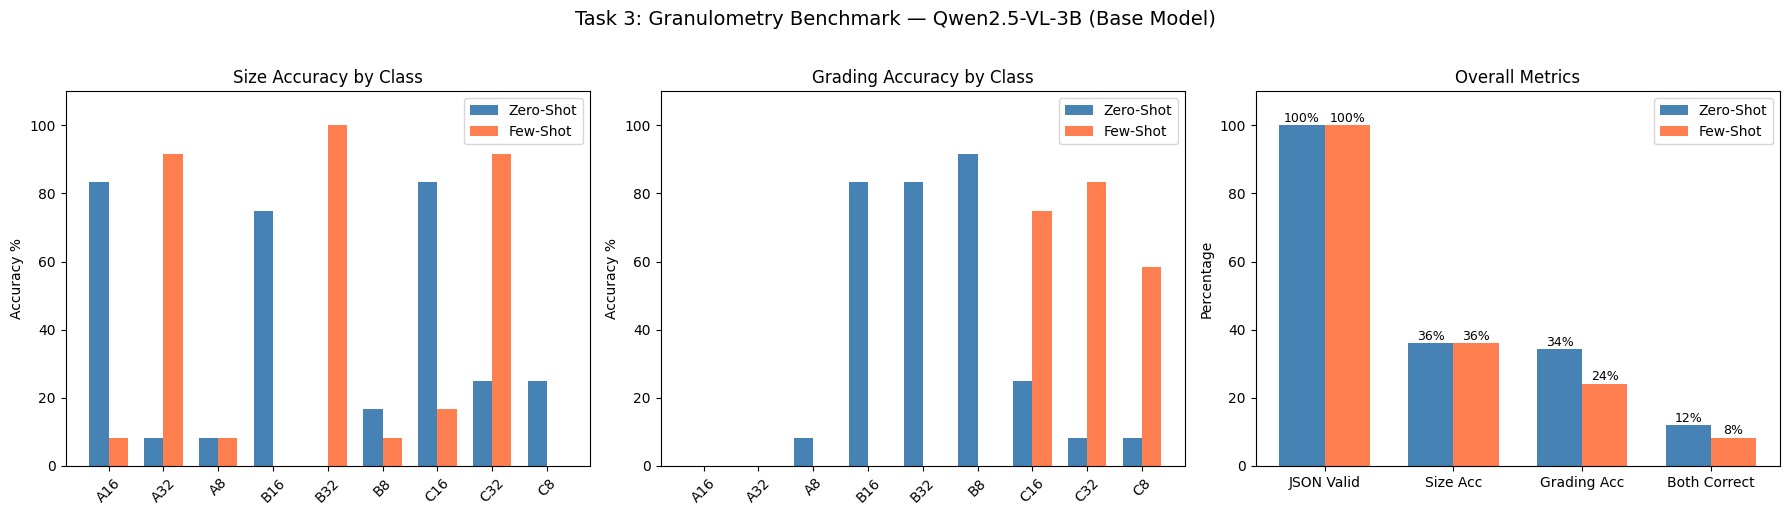

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(classes)); w = 0.35

# Size accuracy
axes[0].bar(x - w/2, [zs_cls[c]['size'] for c in classes], w, label='Zero-Shot', color='steelblue')
axes[0].bar(x + w/2, [fs_cls[c]['size'] for c in classes], w, label='Few-Shot', color='coral')
axes[0].set_xticks(x); axes[0].set_xticklabels(classes, rotation=45)
axes[0].set_ylabel('Accuracy %'); axes[0].set_title('Size Accuracy by Class'); axes[0].legend(); axes[0].set_ylim(0, 110)

# Grading accuracy
axes[1].bar(x - w/2, [zs_cls[c]['grading'] for c in classes], w, label='Zero-Shot', color='steelblue')
axes[1].bar(x + w/2, [fs_cls[c]['grading'] for c in classes], w, label='Few-Shot', color='coral')
axes[1].set_xticks(x); axes[1].set_xticklabels(classes, rotation=45)
axes[1].set_ylabel('Accuracy %'); axes[1].set_title('Grading Accuracy by Class'); axes[1].legend(); axes[1].set_ylim(0, 110)

# Overall comparison
metrics = ['JSON Valid', 'Size Acc', 'Grading Acc', 'Both Correct']
zv = [zs_s['json_pct'], zs_s['size_pct'], zs_s['grading_pct'], zs_s['both_pct']]
fv = [fs_s['json_pct'], fs_s['size_pct'], fs_s['grading_pct'], fs_s['both_pct']]
mx = np.arange(len(metrics))
b1 = axes[2].bar(mx - w/2, zv, w, label='Zero-Shot', color='steelblue')
b2 = axes[2].bar(mx + w/2, fv, w, label='Few-Shot', color='coral')
axes[2].set_xticks(mx); axes[2].set_xticklabels(metrics); axes[2].set_ylim(0, 110)
axes[2].set_ylabel('Percentage'); axes[2].set_title('Overall Metrics'); axes[2].legend()
for bars in [b1, b2]:
    for bar in bars:
        axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.0f}%', ha='center', fontsize=9)

plt.suptitle('Task 3: Granulometry Benchmark — Qwen2.5-VL-3B (Base Model)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


## Save Results

In [21]:
for label, summary, results in [
    ('zero-shot', zs_s, zs_results),
    ('few-shot', fs_s, fs_results),
]:
    fname = f'benchmark_results_{label}.json'
    with open(fname, 'w') as f:
        json.dump({
            'model': 'Qwen2.5-VL-3B-Instruct',
            'mode': label,
            'phase': 'base_model',
            'total_images': summary['n'],
            'json_validity_pct': summary['json_pct'],
            'size_accuracy_pct': summary['size_pct'],
            'grading_accuracy_pct': summary['grading_pct'],
            'both_correct_pct': summary['both_pct'],
            'avg_inference_time_s': summary['avg_time'],
            'results': results,
        }, f, indent=2)
    print(f'Saved {fname}')

print('\nBaseline established. Compare against Task 4 (LoRA fine-tuned) results.')
print(f'Progression: zero-shot → few-shot → fine-tuned')


Saved benchmark_results_zero-shot.json
Saved benchmark_results_few-shot.json

Baseline established. Compare against Task 4 (LoRA fine-tuned) results.
Progression: zero-shot → few-shot → fine-tuned
